In [81]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [82]:
from PIL import Image

In [83]:
(x_train,y_train), (x_test,y_test) = mnist.load_data()

In [84]:
x_train.shape

(60000, 28, 28)

In [85]:
y_train.shape

(60000,)

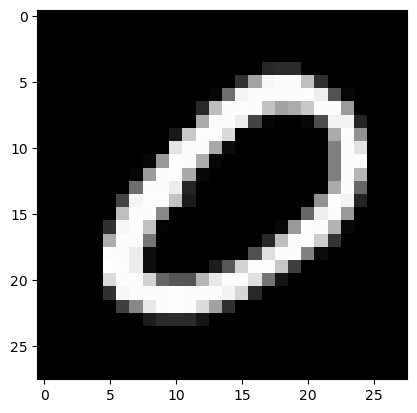

In [86]:
plt.imshow(x_train[453], cmap='gray')

In [87]:
sample_img = x_train[453]

In [88]:
print("top left cornner of img 1\n",sample_img[0:15, 0:15])

top left cornner of img 1
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   6 110]
 [  0   0   0   0   0   0   0   0   0   0   0   0  41 190 252]
 [  0   0   0   0   0   0   0   0   0   0   0   0 171 252 252]
 [  0   0   0   0   0   0   0   0   0   0  25 201 253 253 218]
 [  0   0   0   0   0   0   0   0   0   0 227 252 252 169  11]
 [  0   0   0   0   0   0   0   0   6 153 253 252 171   7   0]
 [  0   0   0   0   0   0   0   6 155 252 253 169   7   0   0]
 [  0   0   0   0   0   0   0 110 252 252 236  37   0   0   0]
 [  0   0   0   0   0   0  68 245 253 253 194  27   0   0   0]]


In [89]:
#Normailze Pixel value b/w 0-1
x_train_norm = x_train.astype('float32')/255.0 #all the 60k images are normalized
x_test_norm = x_test.astype('float32')/255.0 #all the 10k images are normalized

In [90]:
print("top left cornner of img 1\n",x_train_norm[453][0:15, 0:15])

top left cornner of img 1
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.

In [91]:
x_train_norm.min() #min pixel value after normalization

np.float32(0.0)

In [92]:
x_train_norm.max() #max pixel value after normalization

np.float32(1.0)

In [93]:
x_train_norm.shape

(60000, 28, 28)

In [94]:
print("top left cornner of img 1\n",x_train_norm[453][0:15, 0:15])

top left cornner of img 1
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [0.         0.         0.         0.

In [95]:
# demo_convolution = layers.Conv2D(filters=1,kernel_size=(3,3),activation='relu')
# Since the image is very large, supplying only with 1 filter it become time consuming

In [96]:
demo_convolution = layers.Conv2D(filters=4,kernel_size=(3,3),activation='relu')

In [97]:
demo_pooling = layers.MaxPool2D(pool_size=(2,2))

In [98]:
one_img = x_train_norm[0:1]

In [99]:
one_img = np.expand_dims(one_img,axis=-1)
conv_output = demo_convolution(one_img)

In [100]:
pool_output = demo_pooling(conv_output)

In [101]:
conv_output.shape

TensorShape([1, 26, 26, 4])

In [102]:
pool_output.shape

TensorShape([1, 13, 13, 4])

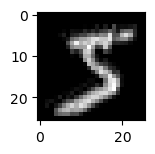

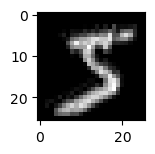

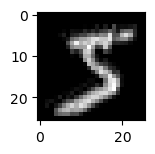

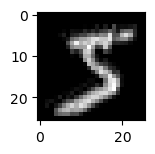

In [103]:
plt.Figure(figsize=(10,10))

for i in range( 4):
    plt.subplot(1,4,i+1)
    plt.imshow(conv_output[0,:,:,1],cmap='gray')
    plt.show()


In [104]:
demo_flatten = layers.Flatten()

flatten_output = demo_flatten(pool_output)

In [105]:
flatten_output.shape

TensorShape([1, 676])

if the current dimention of this input image is 13x13 how will it change after 2nd convolution layer and 2nd pooling layer given kernel 3x3 and pool size is 2x2

In [106]:
#building the CNN Inages Classifier
model = models.Sequential([
    layers.Input(shape=(28,28,1),name='input layer'),
    layers.Conv2D(filters=16,kernel_size=(3,3), activation='relu', name='conv_laye_1'),
    layers.MaxPool2D(pool_size=(2,2), name="max_pool_1"),#[1,13,13,16]
    layers.Conv2D(filters=32,kernel_size=(3,3), activation='relu', name='conv_laye_2'),
    layers.MaxPool2D(pool_size=(2,2), name="max_pool_2"),#[1,5,5,32]
    layers.Flatten(name='faltten_layer'),#5x5x32 = 800 values
    layers.Dense(64,  activation='relu', name='hidden_layer_1'),
    layers.Dense(32,  activation='relu', name='hidden_layer_2'),
    layers.Dense(units=10, activation='softmax',name='output_layer')    
])

In [107]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=["accuracy"]
)

In [108]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_laye_1 (Conv2D)            │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_laye_2 (Conv2D)            │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ faltten_layer (Flatten)         │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,474 (228.41 KB)

 Trainable params: 58,474 (228.41 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
model.fit(x_train_norm,y_train,epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9434 - loss: 0.1865
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9812 - loss: 0.0607
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9862 - loss: 0.0438
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9892 - loss: 0.0344
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9914 - loss: 0.0271
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9929 - loss: 0.0220
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9941 - loss: 0.0184
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9953 - loss: 0.0144
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9959 - loss: 0.0127
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9963 - loss: 0.0109
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9966 - loss: 0.0105
Epoch 12/20
1875/187

In [114]:
test_loss,test_accuracy=model.evaluate(x_test_norm,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9909 - loss: 0.0463


In [115]:
img3 = Image.open(r"testimg\3.png")
img4 = Image.open(r"testimg\4.png")
img8 = Image.open(r"testimg\8.png")

In [118]:
img = img8.convert('L')

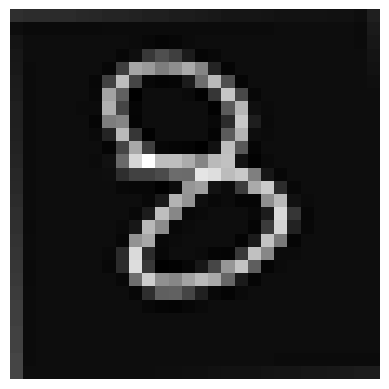

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted digit: 8
Prediction probabilities: [[3.5806102e-04 1.3006183e-04 4.2745230e-01 7.3897247e-03 5.4489980e-03
  3.6373851e-04 4.2773280e-04 1.6477442e-04 5.5442637e-01 3.8381286e-03]]


In [119]:
# Resize to 28x28
img = img.resize((28, 28))

# Convert to NumPy array
img_array = np.array(img)

# If your image has a white background and black digit, invert it
img_array = img_array

# Normalize
img_array = img_array.astype("float32") / 255.0

# Add batch and channel dimensions
img_array = img_array.reshape(1, 28, 28, 1)

# Display image
plt.imshow(img_array[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.show()

# Predict
prediction = model.predict(img_array)

print("Predicted digit:", np.argmax(prediction))
print("Prediction probabilities:", prediction)